# K-Means Clustering Fraud Analysis Model

## Model Plan


In [55]:
from pathlib import Path
import time

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from sklearn.cluster import MiniBatchKMeans
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    precision_recall_curve,
    roc_auc_score,
    silhouette_score,
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 60)

PROJECT_ROOT = Path("..").resolve()
DATA_FILE = PROJECT_ROOT / "data" / "processed" / "cleaned_transactions.csv"
MODEL_DIR = PROJECT_ROOT / "models"
FIGURE_DIR = PROJECT_ROOT / "reports" / "figures"
MODEL_DIR.mkdir(parents=True, exist_ok=True)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

RANDOM_STATE = 42
SAMPLE_SIZE = 500_000
N_CLUSTERS = 2

if not DATA_FILE.exists():
    raise FileNotFoundError("Run src/01_process_data.py first to create cleaned_transactions.csv")

## Load Cleaned Data

In [56]:
use_columns = [
    "id", "date", "amount", "use_chip", "merchant_state", "mcc", "errors", "is_fraud"
]

transactions = pd.read_csv(DATA_FILE, usecols=use_columns)
transactions.shape

(8914963, 8)

In [57]:
transactions["is_fraud"].value_counts(normalize=True).mul(100).round(4).rename("percent")

is_fraud
0    99.8505
1     0.1495
Name: percent, dtype: float64

## Feature Engineering


In [58]:
model_data = transactions.copy()

model_data["date"] = pd.to_datetime(model_data["date"], errors="coerce")
model_data["amount_value"] = pd.to_numeric(
    model_data["amount"].astype(str).str.replace("$", "", regex=False),
    errors="coerce",
)
model_data["abs_amount"] = model_data["amount_value"].abs()
model_data["is_negative_amount"] = (model_data["amount_value"] < 0).astype(int)
model_data["hour"] = model_data["date"].dt.hour
model_data["day_of_week"] = model_data["date"].dt.dayofweek
model_data["month"] = model_data["date"].dt.month
model_data["has_error"] = model_data["errors"].notna().astype(int)

feature_columns = [
    "abs_amount",
    "is_negative_amount",
    "hour",
    "day_of_week",
    "month",
    "use_chip",
    "merchant_state",
    "mcc",
    "has_error",
]

X = model_data[feature_columns]
y = model_data["is_fraud"].astype(int)

pd.DataFrame({"feature": feature_columns})

,feature
0,abs_amount
1,is_negative_amount
2,hour
3,day_of_week
4,month
5,use_chip
6,merchant_state
7,mcc
8,has_error


## Optional Stratified Sampling

In [59]:
if SAMPLE_SIZE is not None and SAMPLE_SIZE < len(X):
    sample_fraction = SAMPLE_SIZE / len(X)
    sample_index = (
        pd.DataFrame({"is_fraud": y})
        .groupby("is_fraud", group_keys=False)
        .sample(frac=sample_fraction, random_state=RANDOM_STATE)
        .index
    )
    X_model = X.loc[sample_index]
    y_model = y.loc[sample_index]
else:
    X_model = X
    y_model = y

sample_summary = pd.DataFrame(
    {
        "label": ["Non-fraud", "Fraud"],
        "rows": [int((y_model == 0).sum()), int((y_model == 1).sum())],
        "percent": [round((y_model == 0).mean() * 100, 4), round((y_model == 1).mean() * 100, 4)],
    }
)
sample_summary

,label,rows,percent
0,Non-fraud,499252,99.8504
1,Fraud,748,0.1496


## Train-Test Split

In [60]:
X_train, X_test, y_train, y_test = train_test_split(
    X_model,
    y_model,
    test_size=0.25,
    stratify=y_model,
    random_state=RANDOM_STATE,
)

split_summary = pd.DataFrame(
    {
        "split": ["train", "test"],
        "rows": [len(X_train), len(X_test)],
        "fraud rows": [int(y_train.sum()), int(y_test.sum())],
        "fraud rate (%)": [round(y_train.mean() * 100, 4), round(y_test.mean() * 100, 4)],
    }
)
split_summary

,split,rows,fraud rows,fraud rate (%)
0,train,375000,561,0.1496
1,test,125000,187,0.1496


## Build K-Means Pipeline

In [61]:
numeric_features = ["abs_amount", "is_negative_amount", "hour", "day_of_week", "month", "has_error"]
categorical_features = ["use_chip", "merchant_state", "mcc"]

numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ]
)

categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore")),
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features),
    ]
)

kmeans_model = MiniBatchKMeans(
    n_clusters=N_CLUSTERS,
    batch_size=8192,
    n_init=10,
    random_state=RANDOM_STATE,
)

kmeans_pipeline = Pipeline(
    steps=[
        ("preprocess", preprocessor),
        ("model", kmeans_model),
    ]
)
kmeans_pipeline

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocess', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the o

## Train Model

In [62]:
start_time = time.perf_counter()
kmeans_pipeline.fit(X_train)
training_time_seconds = time.perf_counter() - start_time
round(training_time_seconds, 2)

1.11

## Complexity and Efficiency Notes


In [63]:
encoded_feature_count = len(kmeans_pipeline.named_steps["preprocess"].get_feature_names_out())
complexity_summary = pd.DataFrame(
    {
        "item": [
            "training rows",
            "test rows",
            "input features before encoding",
            "features after one-hot encoding",
            "number of clusters",
            "batch size",
            "training time seconds",
        ],
        "value": [
            len(X_train),
            len(X_test),
            len(feature_columns),
            encoded_feature_count,
            kmeans_pipeline.named_steps["model"].n_clusters,
            kmeans_pipeline.named_steps["model"].batch_size,
            round(training_time_seconds, 2),
        ],
    }
)
complexity_summary

,item,value
0,training rows,375000.00
1,test rows,125000.00
2,input features before encoding,9.00
3,features after one-hot encoding,265.00
4,number of clusters,2.00
5,batch size,8192.00
6,training time seconds,1.11


## Cluster Evaluation Against Fraud Labels


In [64]:
train_clusters = kmeans_pipeline.predict(X_train)
test_clusters = kmeans_pipeline.predict(X_test)

cluster_profile = (
    pd.DataFrame({"cluster": train_clusters, "is_fraud": y_train.to_numpy()})
    .groupby("cluster")
    .agg(rows=("is_fraud", "size"), fraud_count=("is_fraud", "sum"), fraud_rate=("is_fraud", "mean"))
    .reset_index()
)
cluster_profile["fraud_rate_percent"] = cluster_profile["fraud_rate"] * 100
risk_cluster = cluster_profile.sort_values("fraud_rate", ascending=False).iloc[0]["cluster"]
cluster_profile

,cluster,rows,fraud_count,fraud_rate,fraud_rate_percent
0,0,192755,321,0.001665,0.166533
1,1,182245,240,0.001317,0.131691


In [65]:
y_pred = (test_clusters == risk_cluster).astype(int)

distance_to_centers = kmeans_pipeline.named_steps["model"].transform(
    kmeans_pipeline.named_steps["preprocess"].transform(X_test)
)
anomaly_score = distance_to_centers.min(axis=1)

metrics_summary = pd.DataFrame(
    {
        "model": ["K-Means Clustering"],
        "accuracy": [accuracy_score(y_test, y_pred)],
        "roc_auc_distance_score": [roc_auc_score(y_test, anomaly_score)],
        "pr_auc_distance_score": [average_precision_score(y_test, anomaly_score)],
        "training_time_seconds": [training_time_seconds],
    }
)
metrics_summary.round(4)

,model,accuracy,roc_auc_distance_score,pr_auc_distance_score,training_time_seconds
0,K-Means Clustering,0.4836,0.5958,0.0027,1.1069


In [66]:
print(classification_report(y_test, y_pred, target_names=["Non-fraud", "Fraud-risk cluster"], digits=4))

                    precision    recall  f1-score   support

         Non-fraud     0.9987    0.4834    0.6515    124813
Fraud-risk cluster     0.0016    0.5668    0.0033       187

          accuracy                         0.4836    125000
         macro avg     0.5002    0.5251    0.3274    125000
      weighted avg     0.9972    0.4836    0.6505    125000



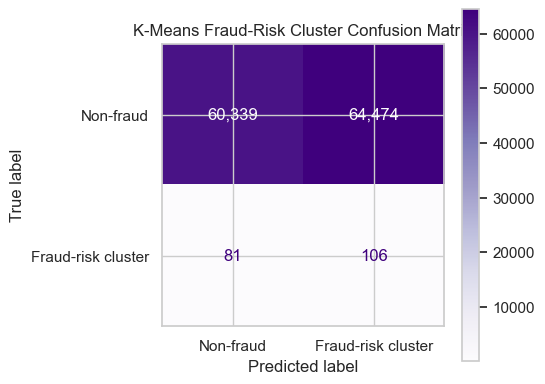

In [67]:
fig, ax = plt.subplots(figsize=(5.5, 4.5))
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    display_labels=["Non-fraud", "Fraud-risk cluster"],
    cmap="Purples",
    values_format=",d",
    ax=ax,
)
ax.set_title("K-Means Fraud-Risk Cluster Confusion Matrix")
fig.tight_layout()
fig.savefig(FIGURE_DIR / "model_kmeans_confusion_matrix.png", dpi=160, bbox_inches="tight")
plt.show()

## Cluster Fraud Rate Figure


## K-Means Cluster Profile


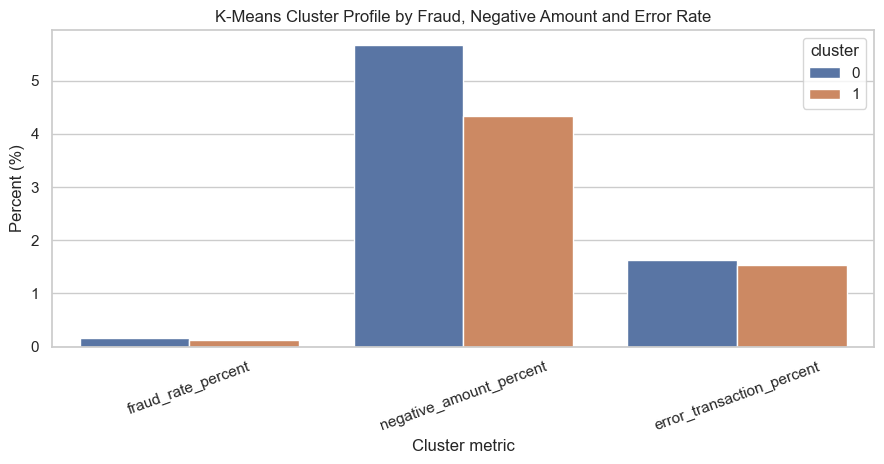

,cluster,transaction_count,fraud_rate_percent,average_amount,negative_amount_percent,error_transaction_percent
0,0,192755,0.1665,56.3296,5.6600,1.6290
1,1,182245,0.1317,49.9606,4.3403,1.5336


In [68]:
cluster_details = X_train.copy()
cluster_details["cluster"] = train_clusters
cluster_details["is_fraud"] = y_train.to_numpy()

cluster_profile_extra = (
    cluster_details.groupby("cluster")
    .agg(
        transaction_count=("is_fraud", "size"),
        fraud_rate_percent=("is_fraud", lambda values: values.mean() * 100),
        average_amount=("abs_amount", "mean"),
        negative_amount_percent=("is_negative_amount", lambda values: values.mean() * 100),
        error_transaction_percent=("has_error", lambda values: values.mean() * 100),
    )
    .reset_index()
)

profile_plot = cluster_profile_extra.melt(
    id_vars="cluster",
    value_vars=["fraud_rate_percent", "negative_amount_percent", "error_transaction_percent"],
    var_name="cluster_metric",
    value_name="percent",
)

fig, ax = plt.subplots(figsize=(9, 4.8))
sns.barplot(data=profile_plot, x="cluster_metric", y="percent", hue="cluster", ax=ax)
ax.set_title("K-Means Cluster Profile by Fraud, Negative Amount and Error Rate")
ax.set_xlabel("Cluster metric")
ax.set_ylabel("Percent (%)")
ax.tick_params(axis="x", rotation=20)
fig.tight_layout()
fig.savefig(FIGURE_DIR / "model_kmeans_cluster_profile.png", dpi=160, bbox_inches="tight")
plt.show()

cluster_profile_extra.round(4)


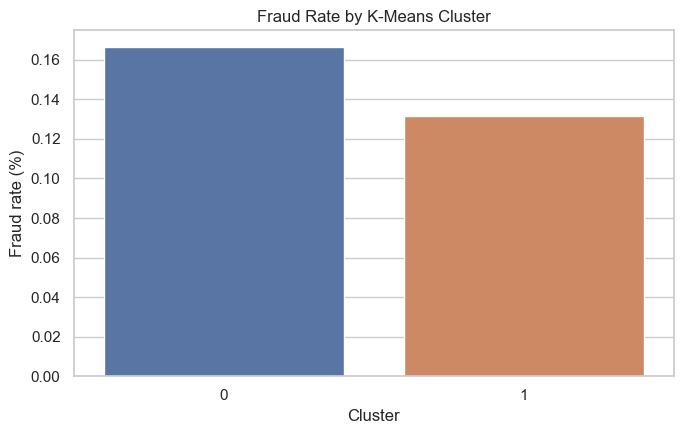

In [69]:
fig, ax = plt.subplots(figsize=(7, 4.5))
sns.barplot(data=cluster_profile, x="cluster", y="fraud_rate_percent", hue="cluster", legend=False, ax=ax)
ax.set_title("Fraud Rate by K-Means Cluster")
ax.set_xlabel("Cluster")
ax.set_ylabel("Fraud rate (%)")
fig.tight_layout()
fig.savefig(FIGURE_DIR / "model_kmeans_cluster_fraud_rate.png", dpi=160, bbox_inches="tight")
plt.show()

## Precision-Recall Curve Using Distance Score



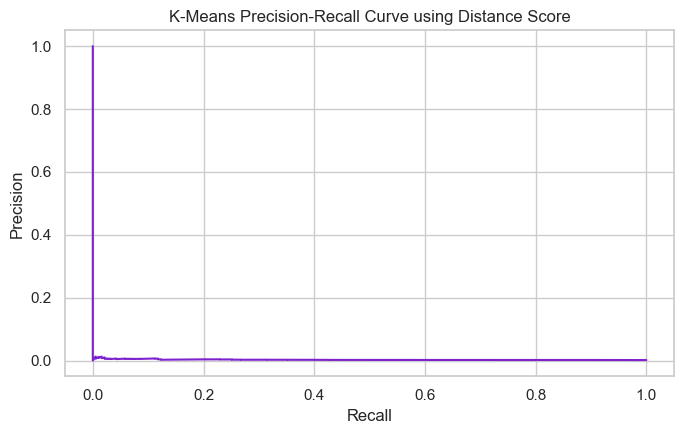

In [70]:
precision, recall, thresholds = precision_recall_curve(y_test, anomaly_score)

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.plot(recall, precision, color="#7e22ce")
ax.set_title("K-Means Precision-Recall Curve using Distance Score")
ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
fig.tight_layout()
fig.savefig(FIGURE_DIR / "model_kmeans_precision_recall_curve.png", dpi=160, bbox_inches="tight")
plt.show()

## Silhouette Score Sample


In [71]:
silhouette_sample_size = min(10_000, len(X_test))
silhouette_sample = X_test.sample(n=silhouette_sample_size, random_state=RANDOM_STATE)
silhouette_features = kmeans_pipeline.named_steps["preprocess"].transform(silhouette_sample)
silhouette_labels = kmeans_pipeline.named_steps["model"].predict(silhouette_features)
silhouette = silhouette_score(silhouette_features, silhouette_labels)
round(silhouette, 4)

0.1043

## Save Model



In [72]:
model_path = MODEL_DIR / "kmeans_fraud_cluster_model.joblib"
joblib.dump(kmeans_pipeline, model_path)
model_path

PosixPath('/Users/zichen/Big-Data-Project/models/kmeans_fraud_cluster_model.joblib')